# 02 — Exploratory Data Analysis

Produces summary statistics, missingness tables, and Pearson/Spearman
correlation matrices for all key variables used in the main analysis.
Outputs saved to `outputs/tables/`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

from src.config import DATA_PATH, OUT_DIR, PRE_DAY, POST_DAY
from src.data_utils import load_panel, build_event_level_dataset
from src.stats import summary_table, missingness_table

TABLES = OUT_DIR / 'tables'
TABLES.mkdir(parents=True, exist_ok=True)

df = load_panel(DATA_PATH)
event, _ = build_event_level_dataset(df, pre_day=PRE_DAY, post_day=POST_DAY)
print('Event-level observations:', len(event))

Event-level observations: 11468


In [2]:
EDA_COLS = [
    'SR', 'UR', 'UR_norm_by_PreIV', 'IV_post',
    'PreSkew', 'PreIV', 'LN_VIX_pre', 'LN_MRKCAP_pre',
    'ret_pre', 'LN_VOL_pre', 'LN_PRC_pre', 'Abs_Ret',
    'Dispersion_pre', 'LN_PC_OI_pre', 'LN_PC_VLM_pre',
    'LN_TOTALVAR_pre', 'IMPKURT_pre', 'LN_EXPTIME_pre',
    'AssetTurnover_pre',
]
eda_cols = [c for c in EDA_COLS if c in event.columns]

## 1. Summary statistics

In [3]:
sumstats = summary_table(event, eda_cols)
sumstats.to_csv(TABLES / 'summary_stats_main_window.csv', index=False)
print('Saved: summary_stats_main_window.csv')
sumstats

Saved: summary_stats_main_window.csv


,variable,N,Mean,Std,Min,P1,P5,Median,P95,P99,Max
0,SR,11468.0,-0.010917,0.069056,-0.335304,-0.184243,-0.122333,-0.010809,0.101998,0.171721,0.382948
1,UR,11468.0,0.330503,0.210600,-0.496494,-0.064497,0.030240,0.306321,0.720966,0.889017,1.347916
2,UR_norm_by_PreIV,11468.0,0.447281,0.514859,-0.711012,-0.059453,0.026751,0.304690,1.378255,2.719773,6.679529
3,IV_post,11468.0,-1.319707,0.342259,-1.961373,-1.961373,-1.841559,-1.352034,-0.706381,-0.402621,-0.201798
4,PreSkew,11468.0,0.078305,0.072236,-0.113336,-0.112270,-0.045493,0.079961,0.194763,0.249042,0.269612
5,PreIV,11468.0,-0.989000,0.347931,-1.961373,-1.715341,-1.536238,-1.006260,-0.367075,-0.201798,-0.201798
6,LN_VIX_pre,11468.0,2.866660,0.312324,2.212660,2.281361,2.407846,2.825537,3.441379,3.652475,4.329548
7,LN_MRKCAP_pre,11466.0,10.531788,1.108385,8.375588,8.424369,8.965751,10.398386,12.534186,13.511920,13.571055
8,ret_pre,11466.0,0.001274,0.019265,-0.190353,-0.048321,-0.029722,0.001197,0.030351,0.051501,0.278694
9,LN_VOL_pre,11466.0,15.163624,1.102396,11.876793,12.873435,13.444405,15.084518,17.123889,18.006894,19.912329


## 2. Missingness

In [4]:
miss = missingness_table(event, eda_cols)
miss.to_csv(TABLES / 'missingness_main_window.csv', index=False)
print('Saved: missingness_main_window.csv')
miss

Saved: missingness_main_window.csv


,variable,missing_count,missing_pct
18,AssetTurnover_pre,71,0.006191
12,Dispersion_pre,54,0.004709
15,LN_TOTALVAR_pre,18,0.001570
11,Abs_Ret,2,0.000174
7,LN_MRKCAP_pre,2,0.000174
10,LN_PRC_pre,2,0.000174
9,LN_VOL_pre,2,0.000174
8,ret_pre,2,0.000174
16,IMPKURT_pre,0,0.000000
3,IV_post,0,0.000000


## 3. Correlations

In [5]:
pearson  = event[eda_cols].corr(method='pearson')
spearman = event[eda_cols].corr(method='spearman')

pearson.to_csv(TABLES  / 'corr_pearson_main_window.csv')
spearman.to_csv(TABLES / 'corr_spearman_main_window.csv')
print('Saved correlation matrices.')
pearson

Saved correlation matrices.


,SR,UR,UR_norm_by_PreIV,IV_post,PreSkew,PreIV,LN_VIX_pre,LN_MRKCAP_pre,ret_pre,LN_VOL_pre,LN_PRC_pre,Abs_Ret,Dispersion_pre,LN_PC_OI_pre,LN_PC_VLM_pre,LN_TOTALVAR_pre,IMPKURT_pre,LN_EXPTIME_pre,AssetTurnover_pre
SR,1.000000,-0.036882,0.004796,0.057532,0.437358,0.034474,-0.020414,-0.095334,0.006437,-0.029465,-0.042391,0.047695,0.024828,0.014817,0.029201,0.055574,0.090815,0.097451,0.000239
UR,-0.036882,1.000000,0.727230,-0.281664,-0.203765,0.327867,-0.250653,0.091965,0.011130,0.127073,0.091785,-0.121645,-0.139969,0.035226,0.042770,-0.113516,-0.251600,-0.404508,0.224669
UR_norm_by_PreIV,0.004796,0.727230,1.000000,0.186683,-0.203215,0.623766,-0.018622,-0.075449,0.014220,0.190984,-0.028810,0.086104,0.005769,0.029944,0.023897,0.244929,-0.055678,-0.343375,0.134059
IV_post,0.057532,-0.281664,0.186683,1.000000,-0.094025,0.813949,0.533116,-0.325996,-0.001827,0.150800,-0.200244,0.408178,0.316525,0.009800,-0.009568,0.815593,0.115282,-0.015382,-0.075602
PreSkew,0.437358,-0.203765,-0.203215,-0.094025,1.000000,-0.216005,0.159070,-0.046070,-0.007172,-0.186816,0.030459,-0.042572,-0.056260,0.008043,0.162948,-0.051929,0.125906,0.222800,-0.045741
PreIV,0.034474,0.327867,0.623766,0.813949,-0.216005,1.000000,0.372754,-0.265277,0.005197,0.225671,-0.141767,0.328506,0.227284,0.030942,0.016165,0.735142,-0.038157,-0.260060,0.061292
LN_VIX_pre,-0.020414,-0.250653,-0.018622,0.533116,0.159070,0.372754,1.000000,0.018280,-0.044000,0.007555,0.026321,0.180348,0.107412,-0.050641,-0.038304,0.427598,0.085153,0.032367,-0.054892
LN_MRKCAP_pre,-0.095334,0.091965,-0.075449,-0.325996,-0.046070,-0.265277,0.018280,1.000000,0.013306,0.411488,0.377657,-0.136545,-0.160027,-0.022893,-0.089942,-0.278778,-0.161390,-0.326997,-0.038553
ret_pre,0.006437,0.011130,0.014220,-0.001827,-0.007172,0.005197,-0.044000,0.013306,1.000000,0.010294,0.022770,0.001669,0.008632,0.071843,0.000173,0.042211,0.002081,-0.019507,0.017537
LN_VOL_pre,-0.029465,0.127073,0.190984,0.150800,-0.186816,0.225671,0.007555,0.411488,0.010294,1.000000,-0.545804,0.061116,0.093375,-0.047692,-0.215555,0.158716,-0.010675,-0.357418,-0.074135


## 4. Time-series count of events per quarter

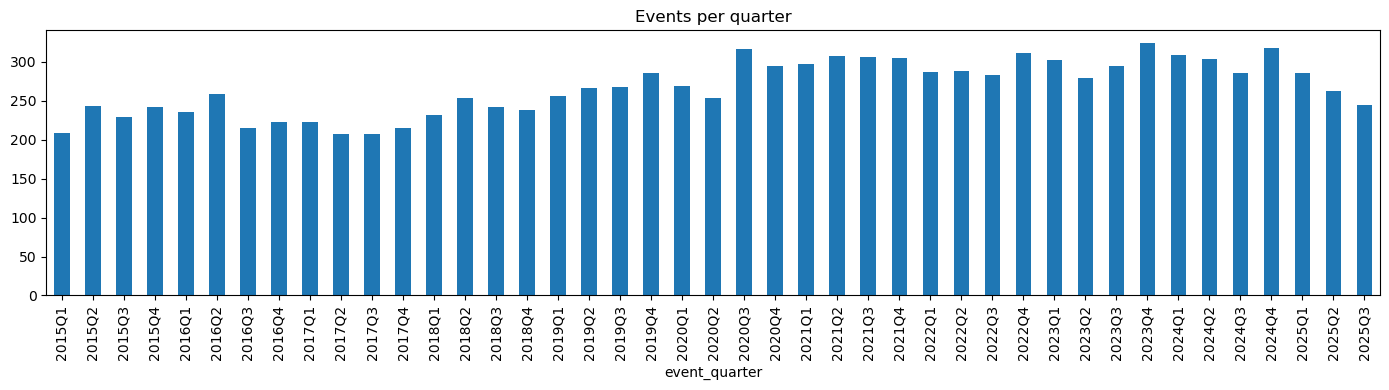

In [6]:
import matplotlib.pyplot as plt
counts = event.groupby('event_quarter').size().rename('n_events')
counts.plot(kind='bar', figsize=(14, 4), title='Events per quarter', rot=90)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'events_per_quarter.png', dpi=150)
plt.show()